# Scada (Network) Aggregate Data Analysis

In [1]:
%%capture
%pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels jupyterlab

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('./data/scada_resolved_agg_30s.csv')
df.head()

,bucket,system_id,protocol,avg_size,source_total_packets,destination_total_packets,min_size,max_size,num_connections,source_ip,...,tcp_psh_count,tcp_rst_count,tcp_syn_count,tcp_fin_count,tcp_syn_ratio,tcp_ack_ratio,modbus_response_count,modbus_response_ratio,avg_modbus_response_code,modbus_response_present
0,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,64.171642,2967,32543,64,65,670,84.3.251.18,...,670,0,0,0,0.000000,1.000000,670,1.0,2.397015,1
1,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,60.000000,18,302,60,60,6,84.3.251.18,...,0,0,0,0,0.000000,1.000000,0,0.0,NaN,0
2,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,65.000000,7,16,65,65,1,84.3.251.18,...,1,0,0,0,0.000000,1.000000,1,1.0,0.000000,1
3,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,60.000000,44,104,60,60,6,84.3.251.18,...,0,2,2,1,0.333333,0.833333,0,0.0,NaN,0
4,2021-04-09 11:30:30+00:00,testbed_system_1,Modbus,65.000000,7,16,65,65,1,84.3.251.18,...,1,0,0,0,0.000000,1.000000,1,1.0,0.000000,1


In [4]:
df.dtypes

bucket                        object
system_id                     object
protocol                      object
avg_size                     float64
source_total_packets           int64
destination_total_packets      int64
min_size                       int64
max_size                       int64
num_connections                int64
source_ip                     object
source_port                  float64
source_mac                    object
destination_ip                object
destination_port             float64
destination_mac               object
source_key                    object
destination_key               object
num_attacks                    int64
attack_types                  object
source_asset                  object
destination_asset             object
tcp_cwr_count                  int64
tcp_ece_count                  int64
tcp_urg_count                  int64
tcp_ack_count                  int64
tcp_psh_count                  int64
tcp_rst_count                  int64
t

In [5]:
# labels least to most severe
y_labels = ['normal', 'anomaly', 'scan', 'dos', 'mitm', 'physical fault']

# map attack_types to a single attack, taking the most severe label
def map_attack_type(attack_types):
    if 'physical fault' in attack_types.lower():
        return 'physical fault'
    elif 'mitm' in attack_types.lower():
        return 'mitm'
    elif 'dos' in attack_types.lower():
        return 'dos'
    elif 'scan' in attack_types.lower():
        return 'scan'
    elif 'anomaly' in attack_types.lower():
        return 'anomaly'
    else:
        return 'normal'
    
df['attack_type'] = df['attack_types'].apply(map_attack_type)
df['attack_type_num'] = df['attack_type'].apply(lambda x: y_labels.index(x)).astype(float)
df[['attack_type', 'attack_type_num']].value_counts()

attack_type     attack_type_num
normal          0.0                161462
dos             3.0                158952
mitm            4.0                 19086
physical fault  5.0                 12590
anomaly         1.0                    87
scan            2.0                    28
Name: count, dtype: int64

In [6]:
df.describe()

,avg_size,source_total_packets,destination_total_packets,min_size,max_size,num_connections,source_port,destination_port,num_attacks,tcp_cwr_count,...,tcp_rst_count,tcp_syn_count,tcp_fin_count,tcp_syn_ratio,tcp_ack_ratio,modbus_response_count,modbus_response_ratio,avg_modbus_response_code,modbus_response_present,attack_type_num
count,352205.000000,3.522050e+05,3.522050e+05,352205.000000,352205.000000,3.522050e+05,351841.000000,351841.000000,3.522050e+05,352205.000000,...,352205.000000,352205.000000,352205.000000,352205.000000,352205.000000,352205.000000,352205.000000,33047.000000,352205.000000,352205.000000
mean,64.750508,2.706741e+03,3.282326e+03,63.599461,66.605429,8.256537e+01,25092.777237,13531.464312,2.449614e+01,0.000088,...,0.131722,1.373981,0.330089,0.560468,0.508622,28.762491,0.093829,220.331378,0.093829,1.749813
std,10.225549,3.226234e+05,3.282198e+05,9.498579,11.385610,3.486503e+03,21959.879547,21267.172522,3.409098e+03,0.014786,...,0.489698,0.914317,0.471367,0.415109,0.452927,516.426177,0.291591,257.458237,0.291591,1.661677
min,60.000000,0.000000e+00,0.000000e+00,60.000000,60.000000,1.000000e+00,0.000000,25.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,0.000000e+00,1.700000e+01,60.000000,60.000000,1.000000e+00,502.000000,502.000000,0.000000e+00,0.000000,...,0.000000,1.000000,0.000000,0.285714,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,60.000000,7.000000e+00,8.100000e+01,60.000000,60.000000,2.000000e+00,22346.000000,502.000000,1.000000e+00,0.000000,...,0.000000,2.000000,0.000000,0.400000,0.666667,0.000000,0.000000,112.000000,0.000000,3.000000
75%,69.142857,4.400000e+01,1.100000e+02,66.000000,74.000000,5.000000e+00,45526.000000,35637.000000,2.000000e+00,0.000000,...,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,411.500000,0.000000,3.000000
max,1514.000000,1.658055e+08,1.658114e+08,1514.000000,1514.000000,1.714034e+06,65535.000000,61646.000000,1.714034e+06,3.000000,...,4.000000,7.000000,8.000000,1.000000,1.000000,10318.000000,1.000000,1831.483781,1.000000,5.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352205 entries, 0 to 352204
Data columns (total 37 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   bucket                     352205 non-null  object 
 1   system_id                  352205 non-null  object 
 2   protocol                   352205 non-null  object 
 3   avg_size                   352205 non-null  float64
 4   source_total_packets       352205 non-null  int64  
 5   destination_total_packets  352205 non-null  int64  
 6   min_size                   352205 non-null  int64  
 7   max_size                   352205 non-null  int64  
 8   num_connections            352205 non-null  int64  
 9   source_ip                  351910 non-null  object 
 10  source_port                351841 non-null  float64
 11  source_mac                 352205 non-null  object 
 12  destination_ip             351910 non-null  object 
 13  destination_port           35

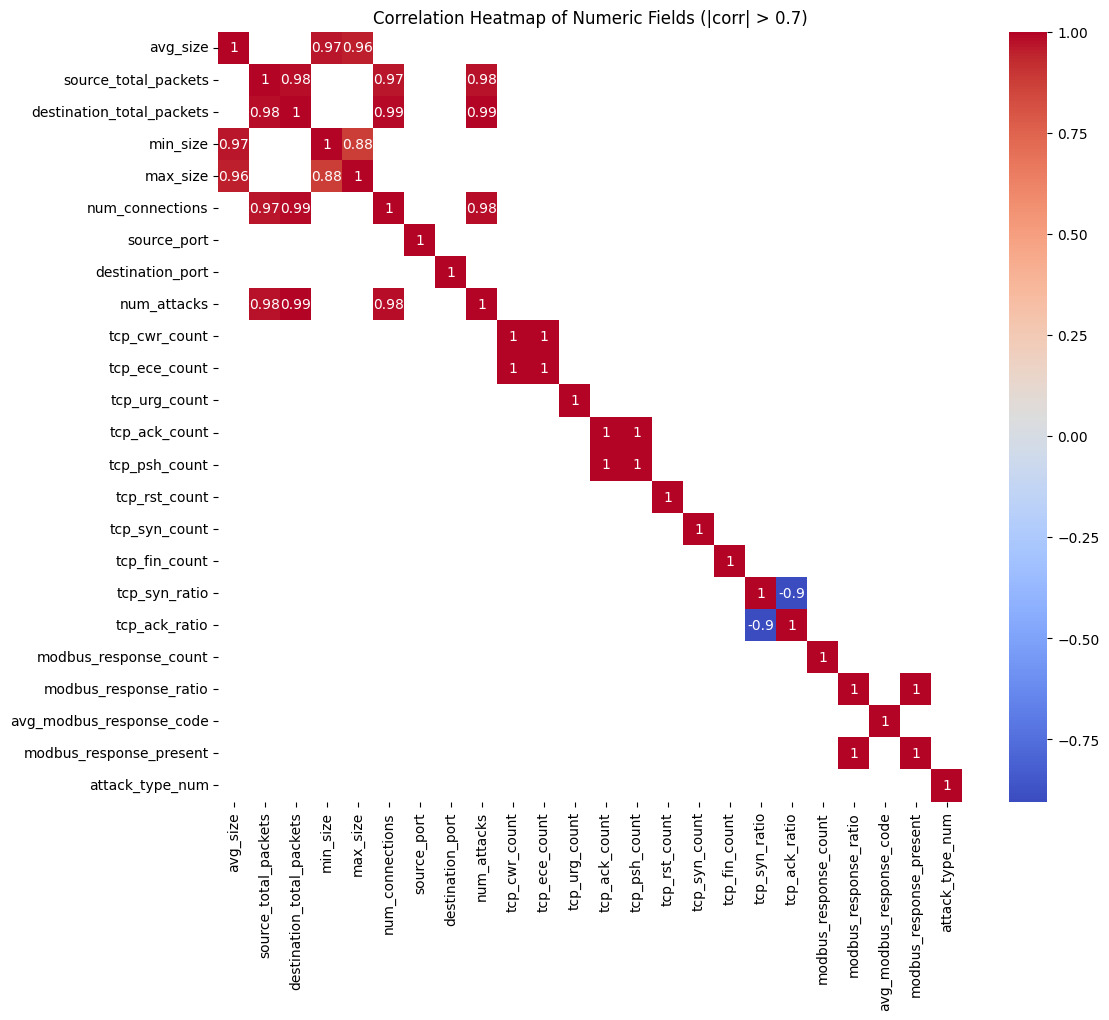

In [8]:
numeric_fields = df.select_dtypes(include=['float64', 'int64'])




# Correlation Heatmap of Numeric Fields with correlation values > 0.7 or < -0.7
plt.figure(figsize=(12, 10))
corr = numeric_fields.corr()
high_corr = corr[(np.abs(corr) > 0.7) ]
sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Fields (|corr| > 0.7)')
plt.show()